<a href="https://colab.research.google.com/github/samuel-lynz/BrainTumorModel/blob/main/braintumor_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ====================== 1. IMPORT LIBRARIES ======================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU Available: []


In [2]:
import os
from google.colab import drive
drive.mount('/content/drive')

import os

base_dir = "/content/drive/MyDrive/Colab Notebooks/archive (2)"

train_dir = os.path.join(base_dir, "Training")
test_dir  = os.path.join(base_dir, "Testing")

print("Training path:", train_dir)
print("Testing path :", test_dir)
print("Training exists:", os.path.exists(train_dir))
print("Testing exists :", os.path.exists(test_dir))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training path: /content/drive/MyDrive/Colab Notebooks/archive (2)/Training
Testing path : /content/drive/MyDrive/Colab Notebooks/archive (2)/Testing
Training exists: True
Testing exists : True


# New Section

In [3]:
import os

# List the contents of your Google Drive's 'My Drive' folder
# Adjust the path if your 'archive (2)' folder is not directly in My Drive
# For example, if it's in a folder called 'Datasets', change to '/content/drive/MyDrive/Datasets'

drive_root_path = '/content/drive/MyDrive'

print(f"Listing contents of: {drive_root_path}")
if os.path.exists(drive_root_path):
    for item in os.listdir(drive_root_path):
        print(item)
else:
    print(f"Error: {drive_root_path} not found. Make sure Google Drive is mounted correctly and the path is valid.")

# After inspecting the output, update the `base_dir` in cell `rjNSsYr7j_mG` with the correct path to your 'archive (2)' folder,
# then rerun cell `rjNSsYr7j_mG` and subsequent cells.

Listing contents of: /content/drive/MyDrive
Colab Notebooks
Brain tumor.gdoc
Machine.gdoc
Hhh.gdoc


In [4]:
import os

def find_folder(name, path):
    """Recursively finds a folder by name within a given path."""
    for root, dirs, _ in os.walk(path):
        if name in dirs:
            return os.path.join(root, name)
    return None

# Search for the 'archive (2)' folder within your entire mounted Google Drive
# This might take a moment if your Drive has many files/folders.
search_path = '/content/drive/MyDrive'
folder_name = 'archive (2)'

found_path = find_folder(folder_name, search_path)

if found_path:
    print(f"Found '{folder_name}' at: {found_path}")
    print("\n--- IMPORTANT ---")
    print(f"Please copy the path above ({found_path}) and update the `base_dir` variable in cell `rjNSsYr7j_mG`.")
    print("After updating, **re-run cell `rjNSsYr7j_mG`**, and then re-run the subsequent cells.")
else:
    print(f"'{folder_name}' not found in {search_path}.")
    print("Please ensure the folder is in your Google Drive and the name is correct, or upload it directly to Colab.")

Found 'archive (2)' at: /content/drive/MyDrive/Colab Notebooks/archive (2)

--- IMPORTANT ---
Please copy the path above (/content/drive/MyDrive/Colab Notebooks/archive (2)) and update the `base_dir` variable in cell `rjNSsYr7j_mG`.
After updating, **re-run cell `rjNSsYr7j_mG`**, and then re-run the subsequent cells.


In [5]:

# ====================== 3. SETTINGS ======================
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20


In [6]:
# ====================== 4. DATA GENERATORS ======================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.15
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nClass indices:", train_generator.class_indices)


Found 4801 images belonging to 4 classes.
Found 847 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [7]:
# ====================== 5. BUILD MODEL ======================
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ====================== 6. CALLBACKS ======================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_brain_tumor_model.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]


In [ ]:
# ====================== 7. TRAIN THE MODEL ======================
print("\n----- Starting Training -----")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks
)



----- Starting Training -----
Epoch 1/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.2600 - loss: 1.4447
Epoch 1: val_accuracy improved from None to 0.25266, saving model to best_brain_tumor_model.h5



Epoch 1: finished saving model to best_brain_tumor_model.h5
151/151 ━━━━━━━━━━━━━━━━━━━━ 1314s 9s/step - accuracy: 0.2554 - loss: 1.4225 - val_accuracy: 0.2527 - val_loss: 1.3864 - learning_rate: 0.0010
Epoch 2/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2538 - loss: 1.3903
Epoch 2: val_accuracy did not improve from 0.25266
151/151 ━━━━━━━━━━━━━━━━━━━━ 518s 3s/step - accuracy: 0.2522 - loss: 1.3911 - val_accuracy: 0.2515 - val_loss: 1.3882 - learning_rate: 0.0010
Epoch 3/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2404 - loss: 1.3885
Epoch 3: val_accuracy did not improve from 0.25266
151/151 ━━━━━━━━━━━━━━━━━━━━ 512s 3s/step - accuracy: 0.2447 - loss: 1.3873 - val_accuracy: 0.2527 - val_loss: 1.3858 - learning_rate: 0.0010
Epoch 4/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2381 - loss: 1.3867
Epoch 4: val_accuracy did not improve from 0.25266
151/151 ━━━━━━━━━━━━━━━━━━━━ 503s 3s/step - accuracy: 0.2393 - loss: 1.3868 - val_accuracy: 0.2527 - val


Epoch 12: finished saving model to best_brain_tumor_model.h5
151/151 ━━━━━━━━━━━━━━━━━━━━ 504s 3s/step - accuracy: 0.2545 - loss: 1.3857 - val_accuracy: 0.3766 - val_loss: 1.3849 - learning_rate: 3.0000e-04
Epoch 13/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2578 - loss: 1.3856
Epoch 13: val_accuracy did not improve from 0.37662
151/151 ━━━━━━━━━━━━━━━━━━━━ 512s 3s/step - accuracy: 0.2593 - loss: 1.3855 - val_accuracy: 0.2527 - val_loss: 1.3855 - learning_rate: 3.0000e-04
Epoch 14/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2645 - loss: 1.3851
Epoch 14: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.

Epoch 14: val_accuracy did not improve from 0.37662
151/151 ━━━━━━━━━━━━━━━━━━━━ 506s 3s/step - accuracy: 0.2620 - loss: 1.3855 - val_accuracy: 0.2527 - val_loss: 1.3860 - learning_rate: 3.0000e-04
Epoch 15/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2608 - loss: 1.3855
Epoch 15: val_accuracy improved from 0.37662 to 0.39669, sav


Epoch 15: finished saving model to best_brain_tumor_model.h5
151/151 ━━━━━━━━━━━━━━━━━━━━ 514s 3s/step - accuracy: 0.2683 - loss: 1.3852 - val_accuracy: 0.3967 - val_loss: 1.3841 - learning_rate: 9.0000e-05
Epoch 16/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2720 - loss: 1.3844
Epoch 16: val_accuracy did not improve from 0.39669
151/151 ━━━━━━━━━━━━━━━━━━━━ 503s 3s/step - accuracy: 0.2649 - loss: 1.3848 - val_accuracy: 0.2550 - val_loss: 1.3840 - learning_rate: 9.0000e-05
Epoch 17/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2563 - loss: 1.3851
Epoch 17: val_accuracy did not improve from 0.39669
151/151 ━━━━━━━━━━━━━━━━━━━━ 500s 3s/step - accuracy: 0.2570 - loss: 1.3854 - val_accuracy: 0.2704 - val_loss: 1.3845 - learning_rate: 9.0000e-05
Epoch 18/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2521 - loss: 1.3856
Epoch 18: val_accuracy improved from 0.39669 to 0.40260, saving model to best_brain_tumor_model.h5



Epoch 18: finished saving model to best_brain_tumor_model.h5
151/151 ━━━━━━━━━━━━━━━━━━━━ 505s 3s/step - accuracy: 0.2589 - loss: 1.3851 - val_accuracy: 0.4026 - val_loss: 1.3839 - learning_rate: 9.0000e-05
Epoch 19/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2682 - loss: 1.3833
Epoch 19: val_accuracy did not improve from 0.40260
151/151 ━━━━━━━━━━━━━━━━━━━━ 503s 3s/step - accuracy: 0.2664 - loss: 1.3841 - val_accuracy: 0.3506 - val_loss: 1.3836 - learning_rate: 9.0000e-05
Epoch 20/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2655 - loss: 1.3848

In [10]:
# ====================== 8. FINE-TUNING ======================
print("\n----- Starting Fine-Tuning -----")
base_model.trainable = True

# Freeze first 100 layers
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks
)



----- Starting Fine-Tuning -----
Epoch 1/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3549 - loss: 1.4731
Epoch 1: val_accuracy did not improve from 0.40260
151/151 ━━━━━━━━━━━━━━━━━━━━ 902s 6s/step - accuracy: 0.3964 - loss: 1.3590 - val_accuracy: 0.2479 - val_loss: 1.3872 - learning_rate: 1.0000e-05
Epoch 2/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4784 - loss: 1.2011
Epoch 2: val_accuracy did not improve from 0.40260
151/151 ━━━━━━━━━━━━━━━━━━━━ 827s 5s/step - accuracy: 0.4968 - loss: 1.1604 - val_accuracy: 0.2680 - val_loss: 1.4808 - learning_rate: 1.0000e-05
Epoch 3/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5266 - loss: 1.0777
Epoch 3: val_accuracy did not improve from 0.40260
151/151 ━━━━━━━━━━━━━━━━━━━━ 810s 5s/step - accuracy: 0.5330 - loss: 1.0703 - val_accuracy: 0.3341 - val_loss: 1.2226 - learning_rate: 1.0000e-05
Epoch 4/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5414 - loss: 1.0424
Epoch 4: val_accuracy improved from


Epoch 4: finished saving model to best_brain_tumor_model.h5
151/151 ━━━━━━━━━━━━━━━━━━━━ 811s 5s/step - accuracy: 0.5551 - loss: 1.0208 - val_accuracy: 0.5844 - val_loss: 0.9937 - learning_rate: 1.0000e-05
Epoch 5/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5498 - loss: 1.0198
Epoch 5: val_accuracy improved from 0.58442 to 0.64581, saving model to best_brain_tumor_model.h5



Epoch 5: finished saving model to best_brain_tumor_model.h5
151/151 ━━━━━━━━━━━━━━━━━━━━ 823s 5s/step - accuracy: 0.5543 - loss: 1.0019 - val_accuracy: 0.6458 - val_loss: 0.8708 - learning_rate: 1.0000e-05
Epoch 6/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5804 - loss: 0.9568
Epoch 6: val_accuracy did not improve from 0.64581
151/151 ━━━━━━━━━━━━━━━━━━━━ 803s 5s/step - accuracy: 0.5940 - loss: 0.9318 - val_accuracy: 0.6316 - val_loss: 0.8767 - learning_rate: 1.0000e-05
Epoch 7/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6061 - loss: 0.9231
Epoch 7: val_accuracy did not improve from 0.64581
151/151 ━━━━━━━━━━━━━━━━━━━━ 808s 5s/step - accuracy: 0.6013 - loss: 0.9274 - val_accuracy: 0.5915 - val_loss: 0.9271 - learning_rate: 1.0000e-05
Epoch 8/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6002 - loss: 0.9336
Epoch 8: val_accuracy did not improve from 0.64581
151/151 ━━━━━━━━━━━━━━━━━━━━ 811s 5s/step - accuracy: 0.6051 - loss: 0.9209 - val_accuracy: 0


Epoch 9: finished saving model to best_brain_tumor_model.h5
151/151 ━━━━━━━━━━━━━━━━━━━━ 808s 5s/step - accuracy: 0.6180 - loss: 0.8873 - val_accuracy: 0.6635 - val_loss: 0.8361 - learning_rate: 1.0000e-05
Epoch 10/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6171 - loss: 0.8872
Epoch 10: val_accuracy improved from 0.66352 to 0.67887, saving model to best_brain_tumor_model.h5



Epoch 10: finished saving model to best_brain_tumor_model.h5
151/151 ━━━━━━━━━━━━━━━━━━━━ 809s 5s/step - accuracy: 0.6288 - loss: 0.8706 - val_accuracy: 0.6789 - val_loss: 0.8182 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 10.


In [11]:
# ====================== 9. EVALUATE ON TEST SET ======================
print("\n----- Evaluating on Test Set -----")
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\n✅ Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"✅ Test Loss    : {test_loss:.4f}")



----- Evaluating on Test Set -----
50/50 ━━━━━━━━━━━━━━━━━━━━ 486s 10s/step - accuracy: 0.6562 - loss: 0.9657

✅ Test Accuracy: 65.62%
✅ Test Loss    : 0.9657


50/50 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step

Classification Report:
              precision    recall  f1-score   support

      glioma       0.81      0.35      0.49       400
  meningioma       0.56      0.49      0.52       400
     notumor       0.76      0.83      0.80       400
   pituitary       0.60      0.95      0.74       400

    accuracy                           0.66      1600
   macro avg       0.68      0.66      0.63      1600
weighted avg       0.68      0.66      0.63      1600



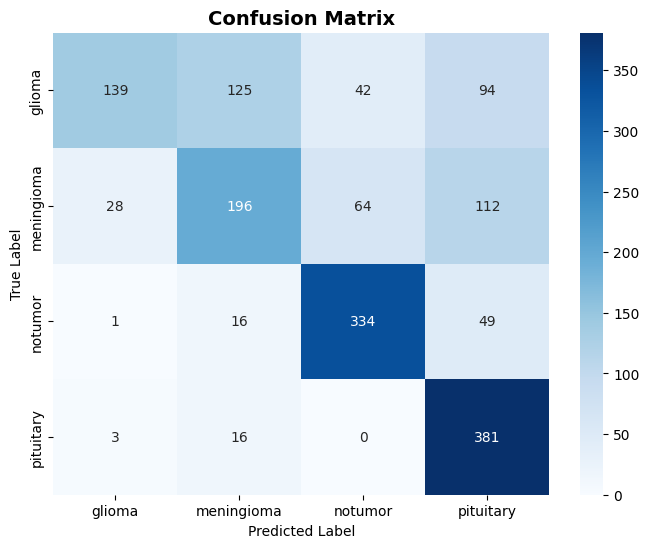

In [12]:
# ====================== 10. PREDICTIONS & METRICS ======================
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_names = list(train_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()



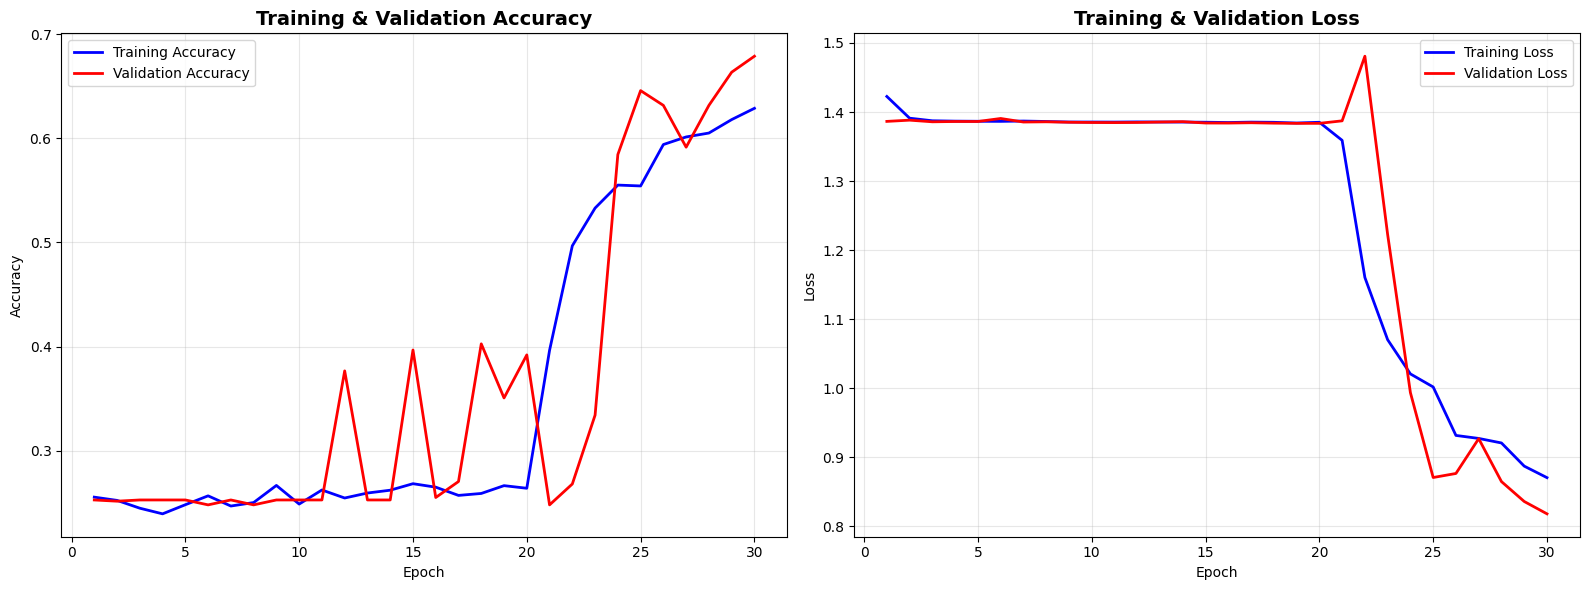

In [14]:
# ====================== 11. LEARNING CURVES (Improved) ======================
def plot_learning_curves(history, history_fine=None):
    if history_fine is not None:
        acc = history.history['accuracy'] + history_fine.history['accuracy']
        val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
        loss = history.history['loss'] + history_fine.history['loss']
        val_loss = history.history['val_loss'] + history_fine.history['val_loss']
    else:
        acc = history.history['accuracy']
        val_acc = history.history['val_accuracy']
        loss = history.history['loss']
        val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(16, 6))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy', linewidth=2)
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
    plt.title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
    plt.title('Training & Validation Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot learning curves
plot_learning_curves(history, history_fine)


In [15]:

# ====================== 12. SAVE THE MODEL ======================
model.save("brain_tumor_efficientnetb0_final.h5")
print("\n✅ Model saved successfully as 'brain_tumor_efficientnetb0_final.h5'")



✅ Model saved successfully as 'brain_tumor_efficientnetb0_final.h5'
